In [6]:
import os
import pickle
from pathlib import Path
from pprint import pprint

import numpy as np
from matplotlib import pyplot as plt

In [7]:
experiment_folder = Path(os.path.join(Path.cwd().parent, 'experiment_data'))

In [59]:
# p = '0.0730'
p = '0.2000'
data_files1 = [
    f'subnetworks-e50-r10-p{p}-t15-s8.pkl',
    f'subnetworks-e50-r10-p{p}-t15-s16.pkl',
    f'subnetworks-e50-r10-p{p}-t15-s32.pkl',
    f'subnetworks-e50-r10-p{p}-t15-s64.pkl',
    f'subnetworks-e50-r10-p{p}-t15-s128.pkl',
    f'subnetworks-e50-r10-p{p}-t15-s256.pkl',
    f'subnetworks-e50-r10-p{p}-t15-s512.pkl',
    f'subnetworks-e50-r10-p{p}-t15-s1024.pkl',
]

In [60]:
p = '0.2000'
data_files2 = [
    f'subnetworks-e50-r10-p{p}-t15-s8.pkl',
    f'subnetworks-e50-r10-p{p}-t15-s40.pkl',
    f'subnetworks-e50-r10-p{p}-t15-s73.pkl',
    f'subnetworks-e50-r10-p{p}-t15-s105.pkl',
    f'subnetworks-e50-r10-p{p}-t15-s138.pkl',
    f'subnetworks-e50-r10-p{p}-t15-s170.pkl',
    f'subnetworks-e50-r10-p{p}-t15-s203.pkl',
    f'subnetworks-e50-r10-p{p}-t15-s235.pkl',
    f'subnetworks-e50-r10-p{p}-t15-s268.pkl',
    f'subnetworks-e50-r10-p{p}-t15-s300.pkl',
]

In [61]:
p = '0.2000'
data_files_all = [
    f'subnetworks-e50-r10-p{p}-t15-s8.pkl',
    f'subnetworks-e50-r10-p{p}-t15-s16.pkl',
    f'subnetworks-e50-r10-p{p}-t15-s40.pkl',
    f'subnetworks-e50-r10-p{p}-t15-s32.pkl',
    f'subnetworks-e50-r10-p{p}-t15-s64.pkl',
    f'subnetworks-e50-r10-p{p}-t15-s73.pkl',
    f'subnetworks-e50-r10-p{p}-t15-s105.pkl',
    f'subnetworks-e50-r10-p{p}-t15-s128.pkl',
    f'subnetworks-e50-r10-p{p}-t15-s138.pkl',
    f'subnetworks-e50-r10-p{p}-t15-s170.pkl',
    f'subnetworks-e50-r10-p{p}-t15-s203.pkl',
    f'subnetworks-e50-r10-p{p}-t15-s235.pkl',
    f'subnetworks-e50-r10-p{p}-t15-s256.pkl',
    f'subnetworks-e50-r10-p{p}-t15-s268.pkl',
    f'subnetworks-e50-r10-p{p}-t15-s300.pkl',
    f'subnetworks-e50-r10-p{p}-t15-s512.pkl',
]

In [75]:
data_files = data_files2

In [76]:
subnetworks = {}

for data_file in data_files:
    full_path = os.path.join(experiment_folder, data_file)

    try:
        with open(full_path, 'rb') as f:
            data = pickle.load(f)
        s = int(data_file.split('-')[-1].strip('.pkls'))

        subnetworks[s] = data 
    except FileNotFoundError:
        print(f"Didn't find file {data_file}")
    
    

In [77]:
keys = list(subnetworks[8].keys())
pprint(keys)

['seeds',
 'config',
 'FC-train-losses',
 'FC-train-accs',
 'FC-test-losses',
 'FC-test-accs',
 'winning-tickets',
 'winning-tickets-full-initializations',
 'winning-ticket-masks',
 'pruned-train-loss-before',
 'pruned-train-acc-before',
 'pruned-test-loss-before',
 'pruned-test-acc-before',
 'pruned-train-loss-after',
 'pruned-train-acc-after',
 'pruned-test-loss-after',
 'pruned-test-acc-after']


In [78]:
train_losses = [subnetworks[s]['FC-train-losses'] for s in subnetworks.keys()]
test_losses = [subnetworks[s]['FC-test-losses'] for s in subnetworks.keys()]
pruned_test_losses = [subnetworks[s]['pruned-test-loss-after'] for s in subnetworks.keys()]
sizes = [s for s in subnetworks.keys()]

In [79]:
train_accs = [subnetworks[s]['FC-train-accs'] for s in subnetworks.keys()]
test_accs = [subnetworks[s]['FC-test-accs'] for s in subnetworks.keys()]
pruned_test_accs = [subnetworks[s]['pruned-test-acc-after'] for s in subnetworks.keys()]

In [80]:
# mean_train_losses = np.array(train_losses).mean(1)
# mean_test_losses = np.array(test_losses).mean(1)
# mean_pruned_test_losses = np.array(pruned_test_losses).mean(1)

In [81]:
NETWORK_ID = 10

In [82]:
mean_train_losses = np.array(train_losses)[:, NETWORK_ID]
mean_test_losses = np.array(test_losses)[:, NETWORK_ID]
mean_pruned_test_losses = np.array(pruned_test_losses)[:, NETWORK_ID]

In [83]:
# mean_train_accs = np.array(train_accs).mean(1)
# mean_test_accs = np.array(test_accs).mean(1)
# mean_pruned_test_accs = np.array(pruned_test_accs).mean(1)

In [84]:
mean_train_accs = np.array(train_accs)[:, NETWORK_ID]
mean_test_accs = np.array(test_accs)[:, NETWORK_ID]
mean_pruned_test_accs = np.array(pruned_test_accs)[:, NETWORK_ID]

In [85]:
print(mean_train_losses)
print(mean_test_losses)
print(mean_pruned_test_losses)

[2.15310320e-01 1.03745749e-02 1.33909273e-03 1.03905935e-04
 2.61001202e-04 9.13747936e-04 1.99422869e-03 1.51992380e-03
 2.17910769e-04 6.98317217e-06]
[0.27164966 0.20164478 0.15887661 0.12853593 0.12784253 0.13309433
 0.13321914 0.14586923 0.12810162 0.12068647]
[0.4833709  0.14740947 0.14404386 0.1772906  0.18954931 0.21012114
 0.18953712 0.19165504 0.20035319 0.17944042]


In [86]:
print(mean_train_accs)
print(mean_test_accs)
print(mean_pruned_test_accs)

[0.93545002 0.99650002 0.99978334 1.         0.99998337 0.99970001
 0.99940002 0.99956667 0.99994999 1.        ]
[0.92329997 0.96699995 0.97599995 0.97959995 0.98049998 0.98039997
 0.98099995 0.98099995 0.98329997 0.98389995]
[0.85459995 0.96149999 0.97109997 0.97709996 0.9788     0.98019999
 0.98159999 0.98199999 0.98209995 0.98209995]


Text(0.5, 1.0, "p='0.2000' | NETWORK_ID=10")

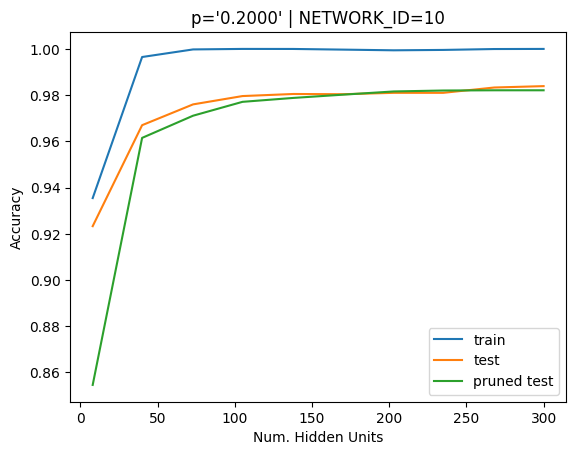

In [87]:
plt.plot(sizes, mean_train_accs, label='train')
plt.plot(sizes, mean_test_accs, label='test')
plt.plot(sizes, mean_pruned_test_accs, label='pruned test')
plt.legend()
plt.xlabel('Num. Hidden Units')
plt.ylabel('Accuracy')
plt.title(f'{p=} | {NETWORK_ID=}')

Text(0.5, 1.0, "p='0.2000' | NETWORK_ID=10")

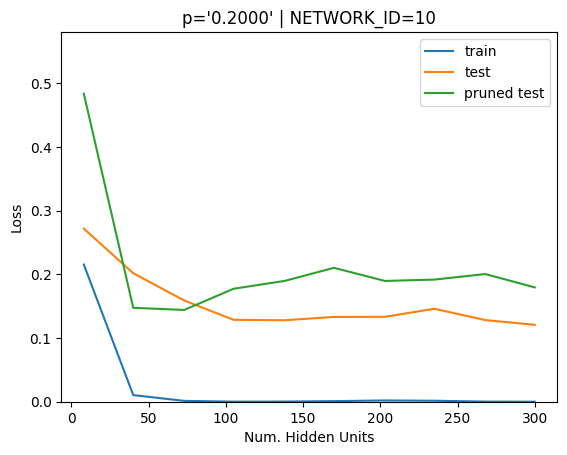

In [88]:
plt.plot(sizes, mean_train_losses, label='train')
plt.plot(sizes, mean_test_losses, label='test')
plt.plot(sizes, mean_pruned_test_losses, label='pruned test')
plt.legend()
plt.ylim(0, 0.58)
# plt.xlim(0, 300)
plt.xlabel('Num. Hidden Units')
plt.ylabel('Loss')
plt.title(f'{p=} | {NETWORK_ID=}')